# Design AI Agents

## Initial Setup

In [1]:
# Install langchain and langchain-openai
# !pip install --upgrade langchain langchain-core langchain-openai langchain-community langgraph

In [2]:
# Show lang chain version
!pip show langchain

Name: langchain
Version: 1.3.1
Summary: Building applications with LLMs through composability
Home-page: https://docs.langchain.com/
Author: 
Author-email: 
License: MIT
Location: /home/worker-user/.local/lib/python3.10/site-packages
Requires: langchain-core, langgraph, pydantic
Required-by: 


In [3]:
# Initial imports
from typing import Annotated
from typing_extensions import TypedDict

from langchain.tools import tool
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from langchain_core.messages.tool import ToolMessage

from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph

## General Parameters

In [4]:
# Select the OpenAI model to use
OPENAI_MODEL: str = "gpt-4o-mini"

## Our First Agent System

In [5]:
# -- 1) Define our single business tool
@tool
def cancel_order(order_id: str) -> str:
    """
    Cancel an order that hasn't shipped.
    """
    
    # (Here you'd call your real backend API)
    pass

    return f"Order {order_id} has been cancelled."

In [6]:
# -- 2) The agent "brain": invoke LLM, run tool, then invoke LLM again
def call_model(state):
    
    msgs = state["messages"]
    order = state.get("order", {"order_id": "UNKNOWN"})
    
    # System prompt tells the model exactly what to do
    prompt = (
    f'''You are an ecommerce support agent.
        ORDER ID: {order['order_id']}
        If the customer asks to cancel, call cancel_order(order_id)
        and then send a simple confirmation.
        Otherwise, just respond normally.'''
    )
    full = [SystemMessage(prompt)] + msgs
    
    # 1st LLM pass: decides whether to call our tool
    first = ChatOpenAI(model=OPENAI_MODEL, temperature=0).invoke(full)
    out = [first]
    
    if getattr(first, "tool_calls", None):
        
        # Run the cancel_order tool
        tc = first.tool_calls[0]
        result = cancel_order(**tc["args"])
        out.append(ToolMessage(content=result, tool_call_id=tc["id"]))
        
        # 2nd LLM pass: generate the final confirmation text
        second = ChatOpenAI(model="gpt-5", temperature=0).invoke(full + out)
        out.append(second)
    
    return {"messages": out}

In [7]:
# Define state schema as a TypedDict
class AgentState(TypedDict):
    order: dict
    messages: Annotated[list[BaseMessage], add_messages]

# -- 3) Wire it all up in a StateGraph
def construct_graph():
    
    g = StateGraph(AgentState)
    g.add_node("assistant", call_model)
    g.set_entry_point("assistant")

    return g.compile()

In [8]:
graph = construct_graph()

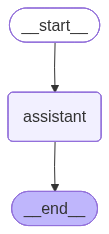

In [9]:
graph

In [10]:
example_order = {"order_id": "A12345"}

In [11]:
convo = [HumanMessage(content="Please cancel my order A12345.")]

In [12]:
result = graph.invoke({"order": example_order, "messages": convo})

In [13]:
for msg in result["messages"]:
    print(f"{msg.type}: {msg.content}")

human: Please cancel my order A12345.
ai: Your order A12345 has been successfully canceled. If you have any other questions or need further assistance, feel free to ask!


In [14]:
# Minimal evaluation check
example_order = {"order_id": "B73973"}
convo = [HumanMessage(content='Please cancel order #B73973. I found a cheaper option elsewhere.')]
result = graph.invoke({"order": example_order, "messages": convo})

In [15]:
# Minimal evaluation checks
assert any(["cancel_order" in str(m.content) for m in result["messages"]]), \
    "Cancel order tool not called"

assert any(["canceled" in m.content.lower() for m in result["messages"]]), \
    "Confirmation message missing"

print("✅ Agent passed minimal evaluation.")    

✅ Agent passed minimal evaluation.


## Core Components of Agent Systems    

### Model Selection

### Tools

#### Designing Capabilities for Specific Tasks

#### Tool Integration and Modularity

### Memory

#### Short Term Memory

#### Long Term Memory

#### Memory Management and Retrieval

### Orchestration

### Design Trade-Offs